In [3]:
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json


# import stim
import deltakit_stim
injections = ['stim._detect_machine_architecture', 'stim._stim_polyfill', 'stim']
for namespace in injections:
    sys.modules[namespace] = sys.modules[f"deltakit_{namespace}"]

import sinter
import multiprocessing
import time
from stimbposd import BPOSD, SinterDecoder_BPOSD


import os
sys.path.append(os.path.abspath("../packages/BeamSearchDecoder"))
from beamsearch import BeamSearch
from sinter_beamsearch import SinterDecoder_BeamSearch

sys.path.append(os.path.abspath("../src"))
from bb_ions import *

In [ ]:
code = gross_code()
p = 0.001
memory_basis = 'X'

circuit = make_BB_circuit(  # see src/bb_ions/circfuncs for explanation of make_BB_circuit inputs
    code,
    p,  
    errors = helios_errors(p),
    idle_during = helios_idle_errors(p),
    num_syndrome_extraction_cycles = code.d_max,  
    memory_basis = memory_basis,
    sequential_gates = True, 
    exclude_opposite_basis_detectors = True,
    reuse_check_qubits = True,
    swap_LRC = False,
    only_CZs = True
)

circuit.to_file("scrap_d=2,b=X.stim")
# svg = circuit.without_noise().diagram('timeline-svg') # diagram without noise
# display(svg)
# svg_string = str(svg)
# with open(f"scrap.svg", "w", encoding="utf-8") as f: f.write(svg_string)

In [5]:
decoder_dictionary = {
    "beam8_230iters": SinterDecoder_BeamSearch(),
    "beam32_340iters": SinterDecoder_BeamSearch(beam_width=32, initial_iters=40, iters_per_round=30),
    "beam64_640iters": SinterDecoder_BeamSearch(max_rounds=20, beam_width=64, initial_iters=40, iters_per_round=30),
    "beam64_32res_640iters": SinterDecoder_BeamSearch(
        max_rounds=20, beam_width=64, num_results=32, initial_iters=40, iters_per_round=30
    ),
    "bp30+osd": SinterDecoder_BPOSD(max_bp_iters=30, bp_method="min_sum", osd_order=10, osd_method="osd_cs")
}

In [ ]:
import glob 
import sinter
circuit_paths = glob.glob(f"../circuits/helios/gross_code/*.stim")
csv_path = "../collected_stats/helios_noise/other_investigations/gross_code_beamsearch.csv"

tasks = [
    sinter.Task(
        circuit_path = path,
        json_metadata = sinter.comma_separated_key_values(path),
    )
    for path in circuit_paths
]

stats = sinter.collect(
        num_workers=multiprocessing.cpu_count(),
        max_shots=35000,
        max_errors=100,
        tasks=tasks,
        decoders=['beam32_340iters'],
        custom_decoders = decoder_dictionary,
        print_progress=True,
        save_resume_filepath = csv_path,
    )

Starting 8 workers...


   3022948,        10,         0, 22838.0,beam32_340iters,2a2c262d9d786ceb3bb345c7d68138985a8474a8eb5123bf1929dc2cd190cc6d,"{""A"":""'300102'"",""B"":""'031020'"",""b"":""X"",""excl_opp_b_detectors"":""True"",""l"":12,""m"":6,""nkd"":""[[144_12_12]]"",""noise"":""helios"",""p"":0.001,""r"":12,""seq_gates"":""True""}",


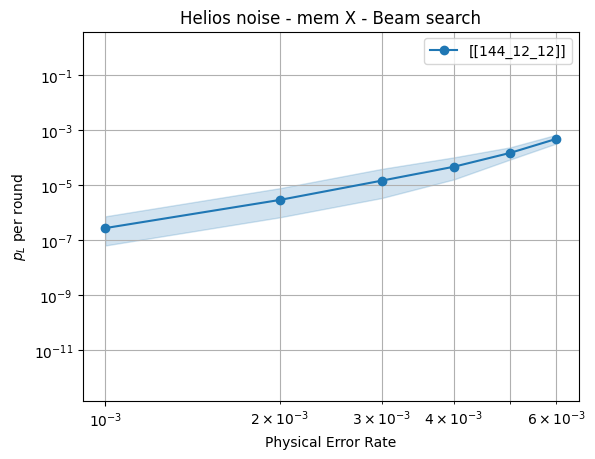

In [19]:
# Plot results:

import matplotlib.pyplot as plt
import sinter
import re

# Plot:
collected_stats = sinter.stats_from_csv_files(f"../collected_stats/helios_noise/other_investigations/gross_code_beamsearch.csv")

for stat in collected_stats:
    if stat.json_metadata['p'] == 0.001:
        print(stat)

fig, ax = plt.subplots(1, 1)

sinter.plot_error_rate(
    ax=ax,
    stats=collected_stats,
    group_func=lambda stats: stats.json_metadata['nkd'],
    x_func=lambda stats: stats.json_metadata['p'],
    failure_units_per_shot_func = lambda stats: stats.json_metadata['r'] # set as num_rounds ('r') failure units to find pL per round
    #  * int(re.search(r'_(\d{1,2})_', stats.json_metadata['nkd']).group(1)) # multiply by k to get per logical qubit
    , 
)

ax.loglog()
ax.legend()
ax.grid()
ax.grid(True, axis = 'x', which = 'minor')
ax.set_ylim(1.3992277047193278e-13, 3.9115107136890295)
ax.set_title("Helios noise - mem X - Beam search")
ax.set_xlabel("Physical Error Rate")
ax.set_ylabel(r"$p_L$ per round");